<a href="https://colab.research.google.com/github/UzmaFatima07/Netflix_Content_Strategy_EDA/blob/main/NetflixContentStrategyEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Load the data

In [ ]:
import pandas as pd
netflix_df = pd.read_csv('/content/drive/MyDrive/NetflixContentStrategyEDAproject/datasets/netflix_titles.csv')

In [ ]:
import os

# List the contents of the 'Netflix Content Strategy EDA project' folder
project_path = '/content/drive/MyDrive/NetflixContentStrategyEDAproject'

print(f"Contents of {project_path}:")
if os.path.exists(project_path):
    for item in os.listdir(project_path):
        print(item)
else:
    print(f"The directory '{project_path}' does not exist. Please check the path to your main project folder.")

Contents of /content/drive/MyDrive/NetflixContentStrategyEDAproject:
notebooks
datasets
models
outputs


#Load the libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


#Handle the 'director' and 'cast' column

In [ ]:
netflix_df['director']=netflix_df['director'].fillna('Unknown')
netflix_df['cast']=netflix_df['cast'].fillna('Unknown')


In [ ]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,831
date_added,10
release_year,0
rating,4
duration,3


#Handle the 'country' column

In [ ]:
mode_country=netflix_df['country'].mode()[0]
netflix_df['country']=netflix_df['country'].fillna('mode_country')

#Drop 'date_added','rating','duration' columns

In [ ]:
netflix_df.dropna(subset=['date_added','rating','duration'],inplace=True)

In [ ]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


#Removing Datatype inconsistency in the 'date_added' column

In [ ]:
netflix_df['date_added']=pd.to_datetime(netflix_df['date_added'],format='mixed',dayfirst=False)

In [ ]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   cast          8790 non-null   object        
 5   country       8790 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8790 non-null   int64         
 8   rating        8790 non-null   object        
 9   duration      8790 non-null   object        
 10  listed_in     8790 non-null   object        
 11  description   8790 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 892.7+ KB


##Feature Engineering

In [ ]:
#create new features-month&year
netflix_df['year_added']=netflix_df['date_added'].dt.year
netflix_df['month_added']=netflix_df['date_added'].dt.month

#Final values after handling transformation and data type inconsistency

In [ ]:
#verify our cleaning and transformation
print("Missing values after cleaning:")
print(netflix_df.isnull().sum())
print("\nData types after transformations:")
print(netflix_df.dtypes)

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

Data types after transformations:
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added              int32
dtype: object


##Exploratory Data Analysis

#Univariate Analysis => Only one variable/feature at a time

In [ ]:
#Distributiob of content type
type_counts=netflix_df['type'].value_counts()
print(type_counts)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


Pie Chart

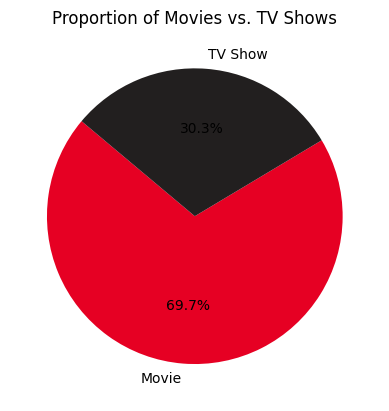

In [ ]:
plt.pie(type_counts,labels=type_counts.index,autopct='%1.1f%%',startangle=140,colors=['#e60023','#221f1f'])
plt.title("Proportion of Movies vs. TV Shows")
plt.ylabel('')
plt.show()

#Has the content added overtime

In [ ]:
#Group data by year and content type
content_over_time=netflix_df.groupby(['year_added','type']).size().unstack().fillna(0)
print(content_over_time)

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      0.0
2010           1.0      0.0
2011          13.0      0.0
2012           3.0      0.0
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         251.0    175.0
2017         836.0    349.0
2018        1237.0    411.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


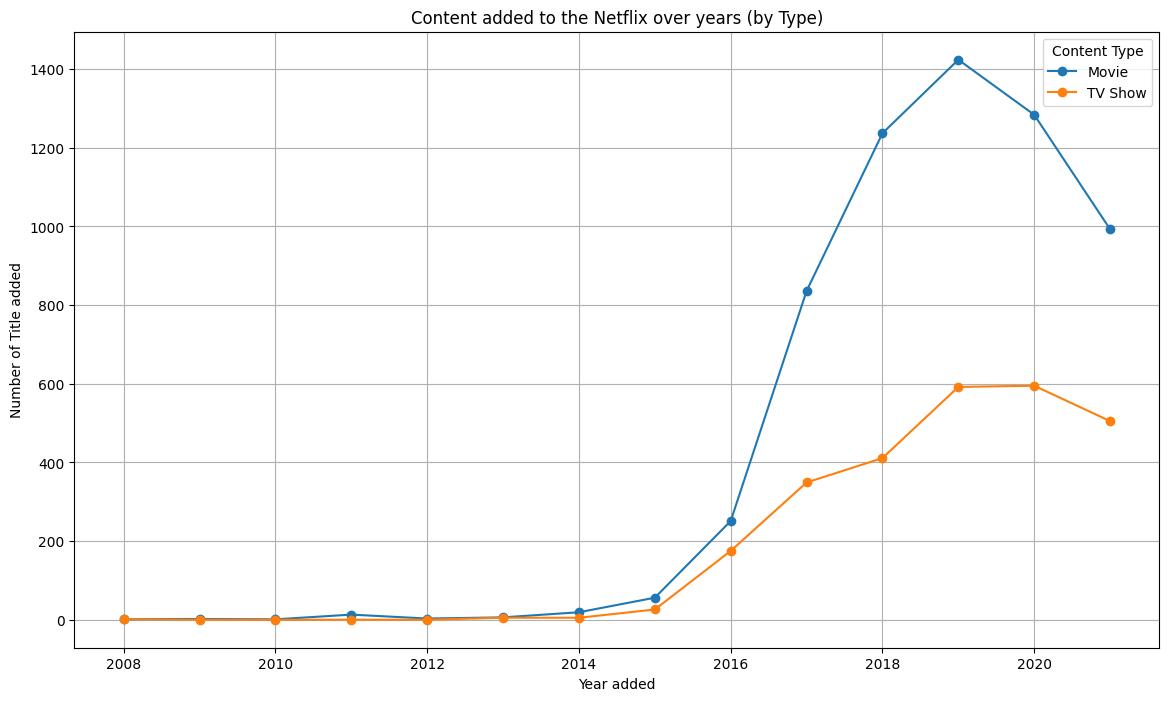

In [ ]:
content_over_time.plot(kind='line',marker='o',figsize=(14,8))
plt.title("Content added to the Netflix over years (by Type)")
plt.xlabel('Year added')
plt.ylabel('Number of Title added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

What are the most popular in genre

In [ ]:
#split the 'listed_in' column and explode it
genres=netflix_df.assign(genre=netflix_df['listed_in'].str.split(',')).explode('genre')
genres


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,Documentaries
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,International TV Shows
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,TV Dramas
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",mode_country,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,Crime TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,Children & Family Movies
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,Comedies
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,Dramas
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,International Movies


Most Popular genre

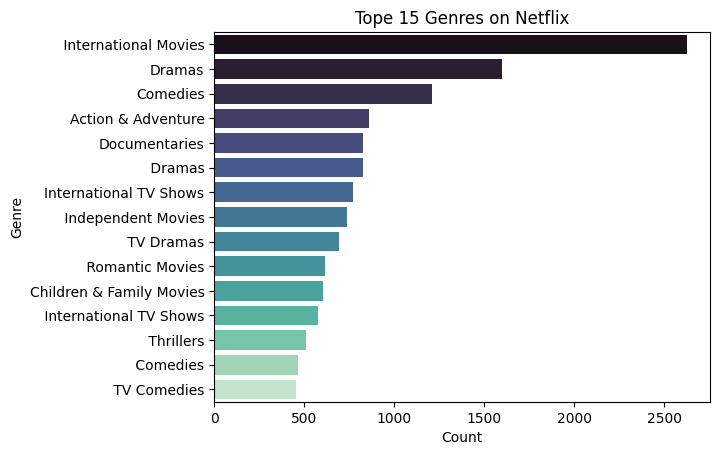

In [ ]:
#get the top 15 genre and their counts
top_genres_counts=genres['genre'].value_counts().reset_index()
#rename columns for clarity
top_genres_counts.columns=['genre','count']
#select only the top 15 for plotting
top_genres_counts_plot=top_genres_counts.head(15)

sns.barplot(y='genre',x='count',data=top_genres_counts_plot,palette='mako',hue='genre',legend=False)
plt.title('Tope 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

#Distribution of content duration

In [ ]:
#separate movies and tv shows
movies_df=netflix_df[netflix_df['type']=='Movie'].copy()
tv_shows_df=netflix_df[netflix_df['type']=='TV Show'].copy()

#clean and convert duration for movies
movies_df['duration_min']=movies_df['duration'].str.replace('min','').astype(int)

#clean and convert duration for tv shows
tv_shows_df['seasons']=tv_shows_df['duration'].str.replace('Seasons','').str.replace('Season','').astype(int)

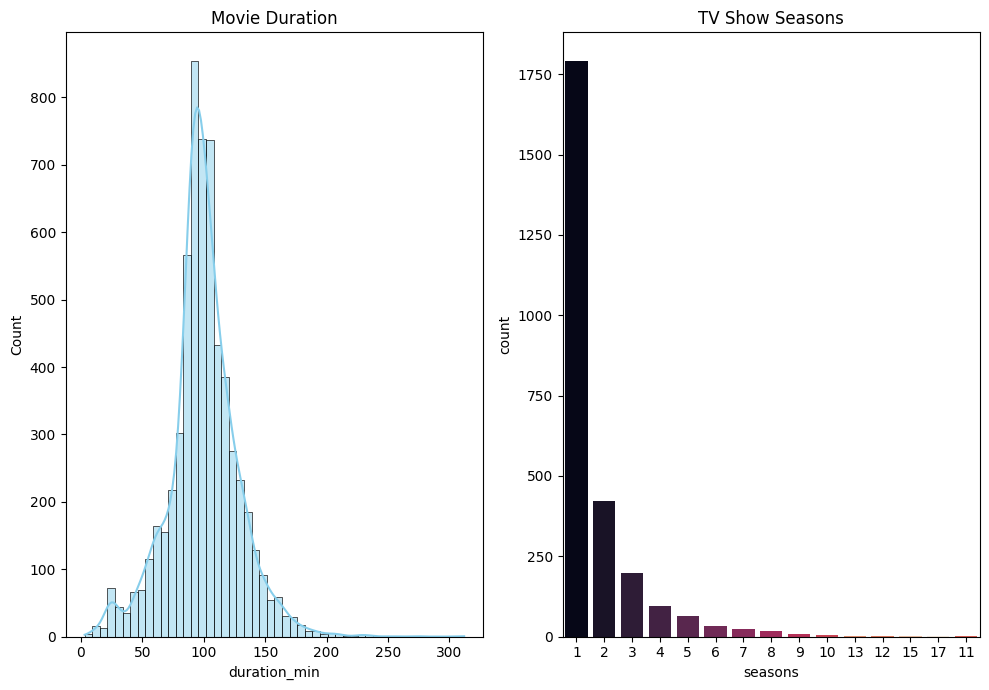

In [ ]:
#Plot the distributions
fig,axes =plt.subplots(1,2,figsize=(10,7))
#Movie duration distribution
sns.histplot(ax=axes[0],data=movies_df,x='duration_min',bins=50,kde=True,color='skyblue')
axes[0].set_title('Movie Duration')

#TV Show seasons distribution
sns.countplot(ax=axes[1],data=tv_shows_df,x='seasons',palette='rocket',order=tv_shows_df['seasons'].value_counts().index, hue='seasons', legend=False)
axes[1].set_title('TV Show Seasons')

plt.tight_layout()
plt.show()

Where does the content comes from

In [ ]:
#Handle the multi country
countries=netflix_df.assign(country=netflix_df['country'].str.split(',')).explode('country')
#get the top 15 countries and their counts
top_countries_counts=countries['country'].value_counts().reset_index()
top_countries_counts.columns=['country','count']
print(top_countries_counts)

            country  count
0     United States   3202
1             India   1008
2      mode_country    829
3    United Kingdom    627
4     United States    479
..              ...    ...
193          Panama      1
194         Namibia      1
195          Uganda      1
196    East Germany      1
197      Montenegro      1

[198 rows x 2 columns]


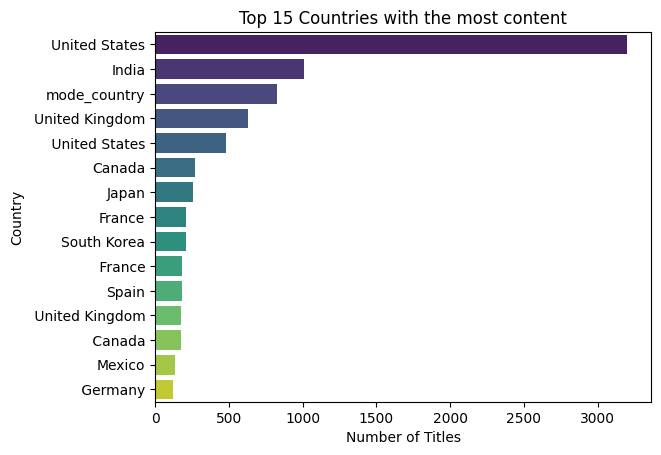

In [ ]:
#select only the top 15 for plotting
top_countries_counts_plot=top_countries_counts.head(15)

sns.barplot(y='country',x='count',data=top_countries_counts_plot,palette='viridis',hue='country',legend=False)
plt.title('Top 15 Countries with the most content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()


Maturity ratings of the content

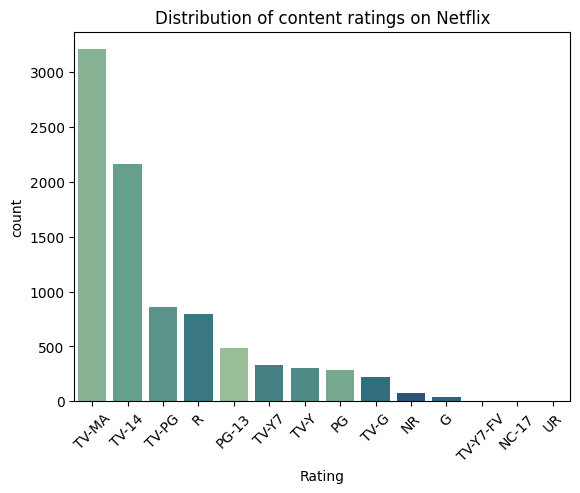

In [ ]:
sns.countplot(x='rating',data=netflix_df,order=netflix_df['rating'].value_counts().index,palette='crest',hue='rating',legend=False)
plt.title('Distribution of content ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

Insight:
a large portion of the netflix content aimed at mature audience,with TV_MA(Mature Audeince) and TV-14(Parents strongly cautioned) being the two most common rating

#Feature Engineering

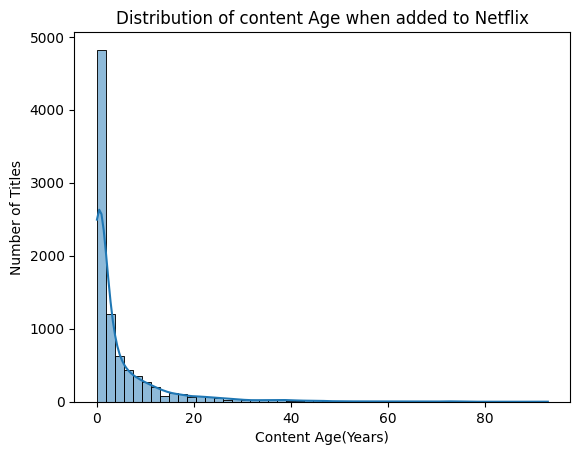

In [ ]:
#create the 'age_on_netflix'feature
netflix_df['age_on_netflix']=netflix_df['year_added']-netflix_df['release_year']

#filter out any potential errors where added_year is before release_year
content_age=netflix_df[netflix_df['age_on_netflix']>=0]

sns.histplot(data=content_age,x='age_on_netflix',bins=50,kde=True)
plt.title('Distribution of content Age when added to Netflix')
plt.xlabel('Content Age(Years)')
plt.ylabel('Number of Titles')
plt.show()


Insight:The large spike at 0indicates that the significant amount of content is being added in the same year,which is the characteristic of the "Netflix Originals".However,there is a very long tall,showing that Netflix also heavily invests in acquiring licensed content that can be decaded old,building a deep library of classic films and TV shows

#Multivariate Analysis

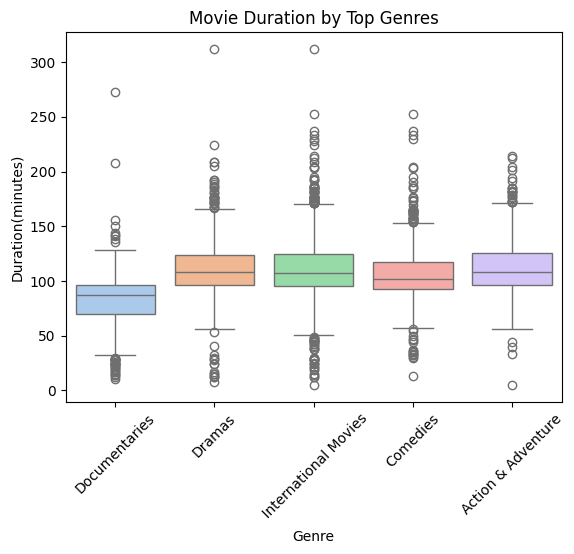

In [ ]:
#Analyze movie duration across different top genres
top_genres=genres['genre'].value_counts().index[:5]
genres_movies=genres[(genres['type']=='Movie')&(genres['genre'].isin(top_genres))].copy()
genres_movies['duration_min']=genres_movies['duration'].str.replace('min','').astype(int)

sns.boxplot(data=genres_movies,x='genre',y='duration_min',palette='pastel',hue='genre',legend=False)
plt.title('Movie Duration by Top Genres')
plt.xlabel('Genre')
plt.ylabel('Duration(minutes)')
plt.xticks(rotation=45)
plt.savefig('boxplot.png')
plt.show()

Insight:Dramas & International Movies have more outliers and reflects the diverse filmmaking styles around the world.

#Word Cloud from the content description

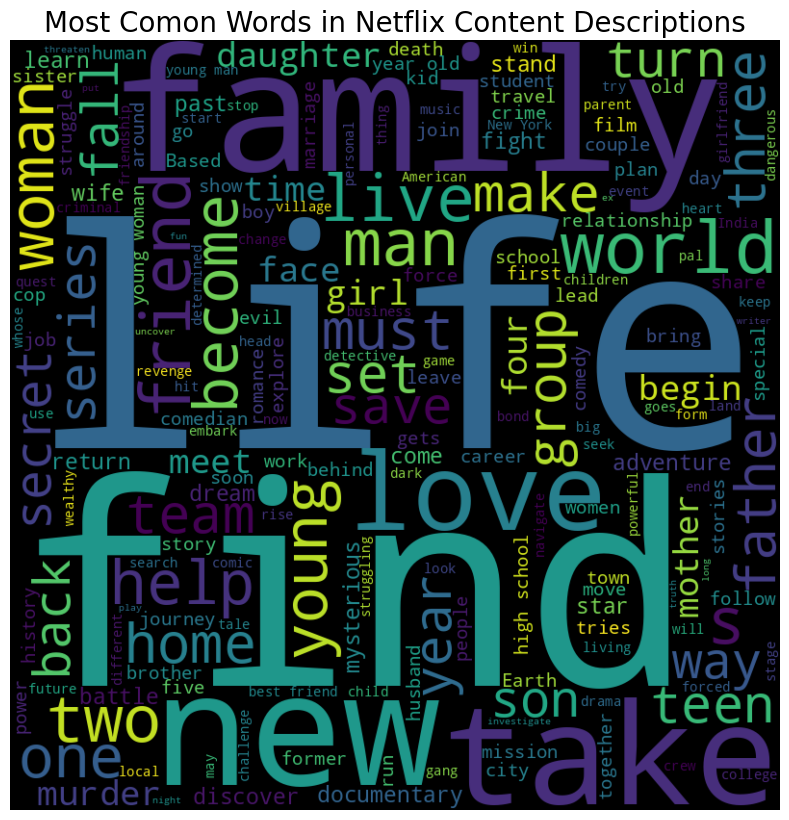

In [ ]:
#combine all description into a single string
text=' '.join(netflix_df['description'])

#create and generate a word cloud image
wordcloud=WordCloud(width=800,height=800,background_color='black').generate(text)

#Display the generated image
plt.figure(figsize=(15,10))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Most Comon Words in Netflix Content Descriptions',fontsize=20)

plt.show()

Insight:The word cloud highlights common themes and subjects.Words like "life","family","love","young","friends" and "world" are prominent suggesting that much of the content revolves around human relationships and personal journeys,Action-oriented words like "find","secret",nd "new" also appear frequently.